In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploring the Association Between Diet and Depression: A Cross-Country Analysis


## Introduction

Depression is one of the leading causes of disability worldwide, affecting an estimated **332 million people** according to the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/depression). It is still widely assumed that depression is primarily a psychological condition - something rooted in thoughts, mindset, or life circumstances. However, growing research suggests that the picture is far more complex.

Evidence points to a significant **physiological component** involving the dysregulation of three interconnected biological systems([Vinkers et al.,2021](https://pubmed.ncbi.nlm.nih.gov/33549878/)):
- The **hypothalamic-pituitary-adrenal (HPA) axis**, which governs the stress response
- The **immune system**, where chronic low-grade inflammation has been linked to depressive episodes ([Berk et al., 2013](https://doi.org/10.1186/1741-7015-11-200))
- The **autonomic nervous system (ANS)**, which regulates involuntary physiological functions

One underexplored factor in this biological pathway is **diet**. Poor nutrition can drive systemic inflammation, disrupt gut microbiota, and impair neurotransmitter synthesis - all mechanisms with plausible links to depression. A 2017 meta-analysis published in *Psychosomatic Medicine* found that a healthy diet was associated with a significantly reduced risk of depression ([Li et al., 2017](https://doi.org/10.1016/j.psychres.2017.04.020)).

Because country-level dietary quality data is difficult to obtain consistently, this project uses **obesity rates as a proxy for poor nutrition**. Obesity is strongly associated with diets high in ultra-processed foods, refined sugars, and low in micronutrients - the same dietary patterns implicated in depression risk 
([Gómez-Donoso et al., 2020](https://doi.org/10.3390/nu14132568)).

This project investigates whether obesity rates correlate with depression rates across countries, using publicly available global health data.

## Hypothesis

Since obesity is strongly associated with poor dietary habits ([Afshin et al., 2019](https://doi.org/10.1016/S0140-6736(19)30041-8)), we use it as a country-level proxy for nutritional quality.

**H1:** Countries with higher obesity rates will show higher rates of depressive disorders.

We will test this both as a **cross-country snapshot** (comparing countries at a single point in time) and as a **within-country trend** (examining whether changes in obesity within a country co-occur with changes in depression over time).

## Data

We use two datasets, both sourced from [Our World in Data](https://ourworldindata.org/):

1. **Mental Health Data** - prevalence of depressive disorders as a share of population, age-standardized, across countries and years.
2. **Obesity Data** - share of adults with BMI ≥ 25 (overweight/obese), age-standardized, across countries and years.

BMI (Body Mass Index) is calculated as:
$$
\mathrm{BMI} = \frac{m}{h^2}
$$
where $m$ is mass in kilograms and $h$ is height in metres. A BMI of 25 or above is classified as overweight by the [WHO](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight).

### Loading the Data

In [3]:
mental_health = pd.read_csv('mental-health-data/mental-illnesses-prevalence.csv')
obesity = pd.read_csv('obesity-data/share-of-adults-who-are-overweight.csv')

In [4]:
mental_health.info(), obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Entity                                                                             6420 non-null   object 
 1   Code                                                                               6150 non-null   object 
 2   Year                                                                               6420 non-null   int64  
 3   Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  6420 non-null   float64
 4   Depressive disorders (share of population) - Sex: Both - Age: Age-standardized     6420 non-null   float64
 5   Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized        6420 non-null   float6

(None, None)

### Merging & Cleaning

The two datasets differ in the number of entities (countries, regions, aggregates) they cover. To ensure we only work with rows that exist in **both** datasets, we perform an inner merge on `Entity` and `Year`. This automatically drops any country-year combinations that appear in only one of the datasets.

In [5]:
mental_health.shape, obesity.shape

((6420, 8), (6798, 4))

In [6]:
mental_health.Entity.nunique(), obesity.Entity.nunique()

(214, 206)

In [7]:
# Merge both tables on Entity and Year (inner join — keeps only shared country-year pairs)
obesity_mental_health_df = pd.merge(mental_health, obesity, on=['Entity', 'Year'])
obesity_mental_health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5970 entries, 0 to 5969
Data columns (total 10 columns):
 #   Column                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                             --------------  -----  
 0   Entity                                                                                                                             5970 non-null   object 
 1   Code_x                                                                                                                             5970 non-null   object 
 2   Year                                                                                                                               5970 non-null   int64  
 3   Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized       

After merging, we reduce the table to only the columns relevant to our analysis and rename them for readability. We will keep the anxiety column for possible further check to compare the results with those for depression.

In [8]:
# Reduce to relevant columns only
obesity_mental_health_df = obesity_mental_health_df[[
    "Entity",
    "Year",
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized",
    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized",
    "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age"
]]

In [9]:
# Rename columns for readability
obesity_mental_health_df = obesity_mental_health_df.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized": "depressive_disorders",
    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized": "anxiety_disorders",
    "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age": "obesity_rate"
})

### Exploratory Overview

In [10]:
obesity_mental_health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5970 entries, 0 to 5969
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               5970 non-null   object 
 1   year                  5970 non-null   int64  
 2   depressive_disorders  5970 non-null   float64
 3   anxiety_disorders     5970 non-null   float64
 4   obesity_rate          5970 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 233.3+ KB


In [11]:
obesity_mental_health_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5970.0,2004.500000,8.656166,1990.000000,1997.000000,2004.500000,2012.000000,2019.000000
depressive_disorders,5970.0,3.780257,0.944505,1.522333,3.066551,3.655919,4.389562,7.645899
anxiety_disorders,5970.0,4.087335,1.067037,1.879996,3.416398,3.932944,4.521156,8.624634
obesity_rate,5970.0,42.927505,19.704198,2.817660,26.453363,46.536270,55.506020,91.284530


In [12]:
# Country with the highest obesity rate in the dataset
obesity_mental_health_df.loc[obesity_mental_health_df['depressive_disorders'].idxmax()]

country                   Uganda
year                        2000
depressive_disorders    7.645899
anxiety_disorders       3.893322
obesity_rate            10.27724
Name: 5560, dtype: object

## Analysis

We approach the hypothesis from two angles:
1. **Cross-country examination** - do countries with higher obesity tend to have higher depression rates?
2. **Within-country examination** - when obesity rises inside a country over time, does depression follow?


### Part 1: Within-Country Examination

**when obesity increases within a specific country over time, does depression also increase?** This approach controls for country-level fixed factors (culture, healthcare, reporting norms) by looking only at *changes* within each country year-over-year.

We compute year-over-year differences for both obesity and depression for each country using `.diff()` grouped by country.

In [13]:
obesity_mental_health_df["obesity_change"] = obesity_mental_health_df.groupby("country")["obesity_rate"].diff()
obesity_mental_health_df["depression_change"] = obesity_mental_health_df.groupby("country")["depressive_disorders"].diff()

In [14]:
# Correlation between year-over-year changes
print(f"Obesity change vs. Depression change: {obesity_mental_health_df['obesity_change'].corr(obesity_mental_health_df['depression_change']):.3f}")

Obesity change vs. Depression change: 0.047


The year-over-year change correlation is essentially **flat** - near zero. To understand why, we can look at a representative country. Depression rates are remarkably stable within individual countries over time, meaning there is very little signal for year-over-year analysis to detect.

The plot below is the average for all countries and illustrates this:

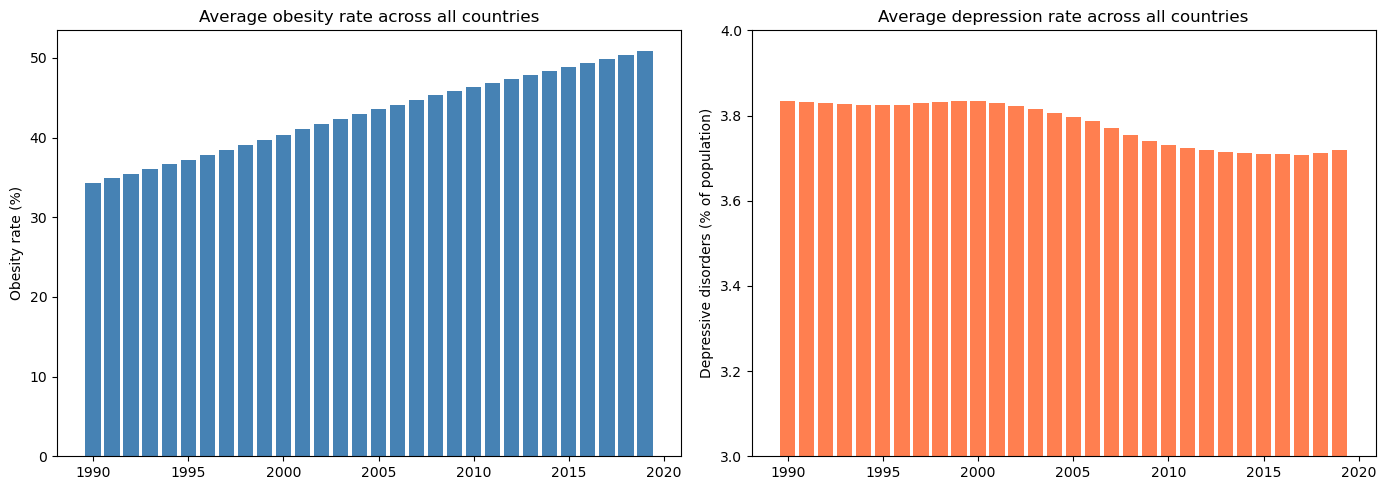

In [15]:
yearly_avg = obesity_mental_health_df.groupby("year")[
    ["obesity_rate", "depressive_disorders"]
].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(yearly_avg.index, yearly_avg["obesity_rate"], color="steelblue")
ax1.set_title("Average obesity rate across all countries")
ax1.set_ylabel("Obesity rate (%)")

ax2.bar(yearly_avg.index, yearly_avg["depressive_disorders"], color="coral")
ax2.set_title("Average depression rate across all countries")
ax2.set_ylabel("Depressive disorders (% of population)")
ax2.set_ylim(3.0, 4.0)

plt.tight_layout()
plt.show()

While obesity rises steadily, depression rates remain almost completely flat within the countries over the same period.

This likely reflects a **methodological limitation of the data** rather than a true absence of effect: country-level prevalence estimates for depression are age-standardized aggregates that change slowly and may not be sensitive enough to capture shorter-term dietary shifts. A within-country approach would require finer-grained data (individual-level or dietary survey data) to be informative.

### Part 2: Cross-Country Examination

We start by looking at a single year snapshot - 2019 - to compare countries at the same point in time. Using a single year avoids the confounding effect of global trends (e.g., both obesity and depression rising everywhere over time simply due to better reporting).

We use Pearson correlation and a regression plot to assess the direction and strength of the relationship.

In [16]:
# Why Am I taking the last year - explain.
obesity_depression_2019 = obesity_mental_health_df[obesity_mental_health_df["year"] == 2019]

In [17]:
# Pearson correlation between obesity rate and depression rate (2019)
obesity_depression_2019["obesity_rate"].corr(obesity_depression_2019["depressive_disorders"])

np.float64(-0.352589199468664)

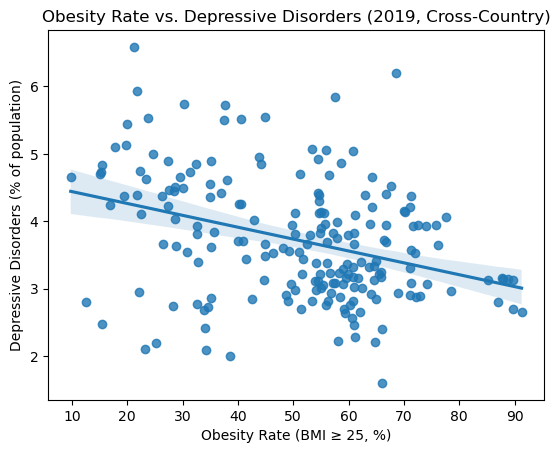

In [18]:
sns.regplot(data=obesity_depression_2019, x="obesity_rate", y="depressive_disorders")
plt.title("Obesity Rate vs. Depressive Disorders (2019, Cross-Country)")
plt.xlabel("Obesity Rate (BMI ≥ 25, %)")
plt.ylabel("Depressive Disorders (% of population)")
plt.show()

A **weak negative association** is observed between obesity and depression across countries. This is a counterintuitive result - it suggests that at the country level, higher obesity does not straightforwardly correspond to higher depression. 

This is likely influenced by confounding variables such as economic development, healthcare access, reporting quality and other health variables contributing to depression.

We could also lokk at it fron another angle - since depression could be caused from lack of nutrients, higher BMI ensures thier supply, thus depression is less.

In [19]:
# Finding possible outliers 
(
    obesity_mental_health_df
    .groupby('country')['depressive_disorders']
    .max()
    .nlargest(20)
)

country
Uganda                          7.645899
Palestine                       7.029476
Greenland                       6.532928
Equatorial Guinea               6.070372
Central African Republic        6.041354
Congo                           6.035825
Angola                          5.957178
Greece                          5.950096
Rwanda                          5.900018
Gabon                           5.779253
Gambia                          5.758524
Democratic Republic of Congo    5.590445
Burundi                         5.548222
Lesotho                         5.511564
Chad                            5.357318
Portugal                        5.335048
Nepal                           5.222565
Morocco                         5.190155
Kenya                           5.170002
Bahrain                         5.136479
Name: depressive_disorders, dtype: float64

#### Segmentation Analysis

Looking at the regression plot, there appears to be a sligth structural difference between countries with lower vs. higher obesity rates - the variability in depression rates increases at lower obesity levels. We split the data at the 45% obesity rate threshold to examine whether the relationship behaves differently in each group.

In [20]:
low = obesity_depression_2019[obesity_depression_2019["obesity_rate"] < 45]
high = obesity_depression_2019[obesity_depression_2019["obesity_rate"] >= 45]

print("Depression correlation:")
print(f"  Low obesity group:  {low['obesity_rate'].corr(low['depressive_disorders']):.3f}")
print(f"  High obesity group: {high['obesity_rate'].corr(high['depressive_disorders']):.3f}")

Depression correlation:
  Low obesity group:  -0.138
  High obesity group: -0.128


The negative association that appeared in the overall data **weakens significantly after segmentation**. This is an example of [**Simpson's Paradox**](https://en.wikipedia.org/wiki/Simpson%27s_paradox) - a trend that appears in aggregated data can disappear or reverse when the data is split into subgroups. Here, the overall correlation is likely being driven by structural differences *between* the two groups (e.g., low-obesity countries being predominantly lower-income with different reporting norms) rather than a genuine within-group relationship between obesity and depression.

We confirm this pattern holds across all years, not just 2019:

In [21]:
# Overall correlation across all countries and all years
print("Overall (all years):")
print(f"  Obesity vs. Depression: {obesity_mental_health_df['obesity_rate'].corr(obesity_mental_health_df['depressive_disorders']):.3f}")

Overall (all years):
  Obesity vs. Depression: -0.335


In [22]:
# Segmented correlation across all years
low_all = obesity_mental_health_df[obesity_mental_health_df["obesity_rate"] < 45]
high_all = obesity_mental_health_df[obesity_mental_health_df["obesity_rate"] >= 45]

print("Depression correlation (all years, segmented):")
print(f"  Low obesity group:  {low_all['obesity_rate'].corr(low_all['depressive_disorders']):.3f}")
print(f"  High obesity group: {high_all['obesity_rate'].corr(high_all['depressive_disorders']):.3f}")

Depression correlation (all years, segmented):
  Low obesity group:  -0.279
  High obesity group: -0.131


The segmentation finding holds across all years. The relationship between obesity and depression varies depending on the level of aggregation, and disappears within homogeneous subgroups - reinforcing the Simpson's Paradox interpretation, suggesting there is no correlation between onbesity and depression.

#### High Income Countries

In [23]:
high_income_countries = [
    'Australia', 'Austria', 'Belgium', 'Canada', 'Denmark',
    'Finland', 'France', 'Germany', 'Ireland', 'Italy',
    'Japan', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
    'Spain', 'Sweden', 'Switzerland', 'United Kingdom', 'United States'
]

oecd_df = obesity_mental_health_df[obesity_mental_health_df['country'].isin(high_income_countries)]
print(f'Countries included: {oecd_df["country"].nunique()}')
print(f'Year range: {oecd_df["year"].min()} to {oecd_df["year"].max()}')

Countries included: 20
Year range: 1990 to 2019


In [24]:
oecd_avg = oecd_df.groupby('country')[['obesity_rate', 'depressive_disorders']].mean().reset_index()

corr_oecd = oecd_avg['obesity_rate'].corr(oecd_avg['depressive_disorders'])
print(f'OECD correlation (obesity vs depression): {corr_oecd:.3f}')

OECD correlation (obesity vs depression): 0.613


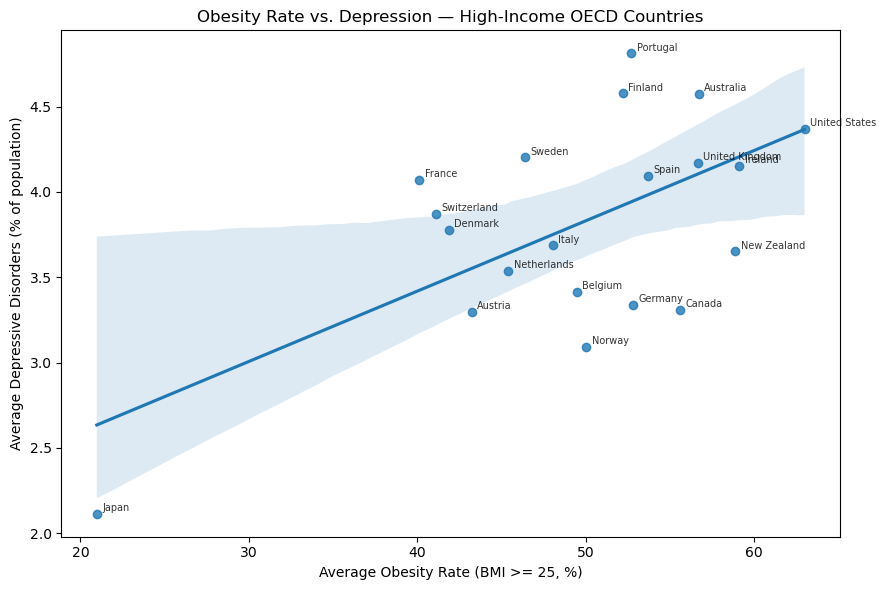

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=oecd_avg, x='obesity_rate', y='depressive_disorders', ax=ax)

for _, row in oecd_avg.iterrows():
    ax.annotate(row['country'], (row['obesity_rate'], row['depressive_disorders']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')

ax.set_title('Obesity Rate vs. Depression — High-Income OECD Countries')
ax.set_xlabel('Average Obesity Rate (BMI >= 25, %)')
ax.set_ylabel('Average Depressive Disorders (% of population)')
plt.tight_layout()
plt.show()